# Inverse Compton Emission
This Notebook contains 4 exercises for a total of 15 marks. Please submit on Ulwazi.

## Pre-Requisites
As usual, we start with importing the necessary modules.

In [1]:
from astropy import units as u
from astropy import constants as c

from astropy.modeling.powerlaws import PowerLaw1D

import numpy as np

import matplotlib.pyplot as plt

from math import pi
from numpy import sqrt, cos, sin, tan, abs

## IC frequency
The frequency $\nu_s$ of the scattered photon can be calculated with the equation on slide 69 of the lecture:
$$
h \nu_s = \frac{4}{3} \left( \frac{U}{m c^2} \right)^2 h \nu
$$
where $U$ is the energy of the electron and $\nu$ is the frequency of the incoming photon. We will deal only with electrons, so the mass can be set to the electron mass. 

### Exercise
Write a function to calculate the IC_frequency.
Make sure that you are in the Thomson limit, your function should return an error (or at least make a print statement) if this is not the case.

**[3 marks]**

In [2]:
def IC_frequency(U, nu) :
        
    # your code here
    nu_s = (4/3) * ( U / ( c.m_e * c.c**2 ) )**2 * nu    
    return nu_s.to(u.Hz)

Let's test it with the lecture example. The energy of the electron is

In [3]:
U = 19 * u.TeV

The scattering is off the Cosmic Microwave Background (CMB) which has a temperature of

In [4]:
T_CMB = 2.7 * u.K

We will take the photon frequency of the peak of the black-body spectrum. We should use Wien's displacement law in its frequency-dependent form. But we are a bit sloppy and take the peak in wavelength
$$
\lambda_\mathsf{peak} = \frac{b}{T}
$$
and convert it to frequency:
$$
\nu_\mathsf{CMB} = \frac{c}{\lambda_\mathsf{peak}}
$$

In [5]:
nu_CMB = c.c * T_CMB / c.b_wien

In [6]:
nu_CMB.to(u.Hz)

<Quantity 2.79331724e+11 Hz>

In [7]:
IC_frequency(U, nu_CMB)

<Quantity 5.14903905e+26 Hz>

Expected output:

$5.149039\times10^{26}$ Hz

## Energy Loss
The energy loss of the electron due to inverse Compton scattering is given by the equation on slide 75 of the lecture:
$$
\frac{dE}{dt} = \frac{4}{3} \sigma_T c \beta^2 \left( \frac{U}{mc^2} \right)^2 u_\mathsf{rad}
$$
where $U$ is the energy of th electron and $u_\mathsf{rad}$ is the energy density of the radiation field.

### Exercise
Write a function for the inverse Compton energy loss. We will use the energy density of the CMB of $0.25\,\mathsf{eV}/\mathsf{cm}^3$ as default value.

**[3 marks]**

In [10]:
def IC_EnergyLoss (U, u_rad = 0.25 *u.eV/u.cm**3, beta = 1) :
    
    # your code here
    dEdt = (4/3) * c.sigma_T * c.c * beta**2 * ( U / ( c.m_e * c.c**2 ) )**2 * u_rad

    return dEdt.to(u.W)

Let's test it with the lecture example.

In [11]:
IC_EnergyLoss(U)

<Quantity 1.47251327e-18 W>

Expected output:

$1.4725133\times10^{-18}$ W

## Inverse Compton Cooling Time
The inverse Compton cooling time is given by the equation on slide 20 of the  "Inverse Compton Emission I" lecture:
$$
\tau_\mathsf{IC} = \frac{3}{4} \frac{c^3 m^2}{\sigma_T \beta^2 u_\mathsf{rad} U}
$$

### Exercise
Write a function for the cooling time.

**[3 marks]**

In [12]:
def CoolingTime_IC(U, u_rad = 0.25 *u.eV/u.cm**3, beta = 1) :
    
    # your code here
    tau = (3/4) * ( c.c**3 * c.m_e**2 ) / ( c.sigma_T * beta**2 * u_rad * U )    
    return tau.to(u.s)

Let's test the function for an array of four electron energies:

In [13]:
U = [1e-1, 1, 10] * u.TeV

In [14]:
CoolingTime_IC (U)

<Quantity [3.92788151e+14, 3.92788151e+13, 3.92788151e+12] s>

Expected output:

[$3.9278815\times10^{14}$, $3.9278815\times10^{13}$, $3.9278815\times10^{12}$] s

Make a plot of the cooling time vs. electron energy for electron energies between 1 MeV and 100 TeV.

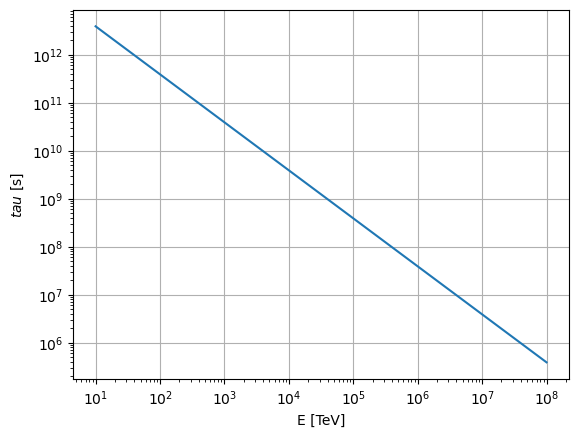

In [35]:
# your code here
U = np.logspace(1, 8, 100) * u.TeV
tau = CoolingTime_IC(U)
plt.plot(U, tau)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('E [{}]'.format(U.unit))
plt.ylabel('$tau$ [{}]'.format(tau.unit))
plt.grid(True)


Expected output:


## Inverse Compton Spectrum
The inverse Compton spectrum (see lecture slide 4 of "Inverse Compton Emission II") is given by
$$
\frac{ dN }{ dt ~ d\nu } (\nu)
=
\frac{ 3 \sigma_T c n_\mathsf{\nu 0} }{ 16 \gamma^4 \nu_0^2 }
	\left[ 
		2 \nu \ln \frac{\nu }{ 4 \gamma^2 \nu_0 }
    + \nu
		+ 4 \gamma^2 \nu_0
		- \frac{ \nu^2 }  { 2 \gamma^2 \nu_0 }
	\right]
$$
This returns the number of photons scattered per time $dt$ into the frequency $\nu$. \$nu_0$ is the frequency of the incoming photon, $\gamma$ is the Lorentz factor of the electron.

In [18]:
def ICspectrum(gamma, nu, nu_0 = 3e11*u.Hz, n_nu0 = 1*u.m**-3) :
    
    const = 3 * c.sigma_T * c.c * n_nu0 / 16/ gamma**4 / nu_0**2
    
    fac = 2*nu*np.log(nu/4 / gamma**2 / nu_0)
    
    fac += nu
    
    fac += 4 * gamma**2 * nu_0
    
    fac += -1* nu**2 / 2 / gamma**2 / nu_0
        
    ret = fac*const
        
    return ret

We will need the Lorentz factor $\gamma$ of the electron.

In [19]:
def gamma_fromEtot (E, m = c.m_e) :
    
    gamma = E/(m*c.c**2)
    
    # gamma is dimensionless, let's decompose before returning
    return gamma.decompose()

In [20]:
frequencies = np.logspace(18, 28, 501) * u.Hz

In [21]:
ic = ICspectrum(gamma_fromEtot(19*u.TeV), frequencies)

In order to get the energy rather than the number of photons we have to multiply with $h \times \nu$:

In [22]:
ic *= (c.h * frequencies)

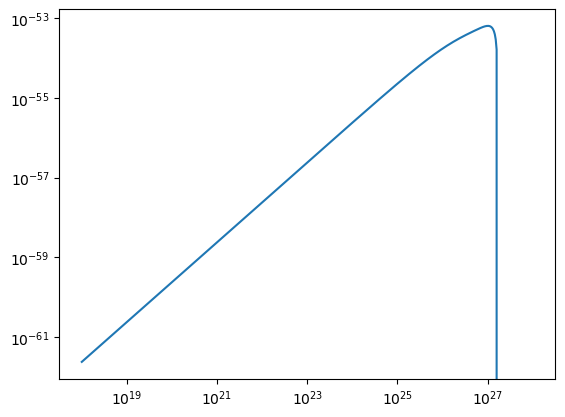

In [23]:
plt.loglog(frequencies, ic)

#plt.ylim(1e-54)

### Exercise
Make the plots as on slides 6 and 7 on "Inverse Compton Emission II". The first plot should show the IC spectra for electrons with energies of 10 GeV, 100 GeV, 1 TeV and 10 TeV. The incoming photon frequency $\nu_0$ remains the default value of $3 \times 10^{11}\,\mathsf{Hz}$. 

**[6 marks]**

In [24]:
U = [0.01, 0.1, 1, 10] * u.TeV

W / Hz


(1e+17, 1e+27)

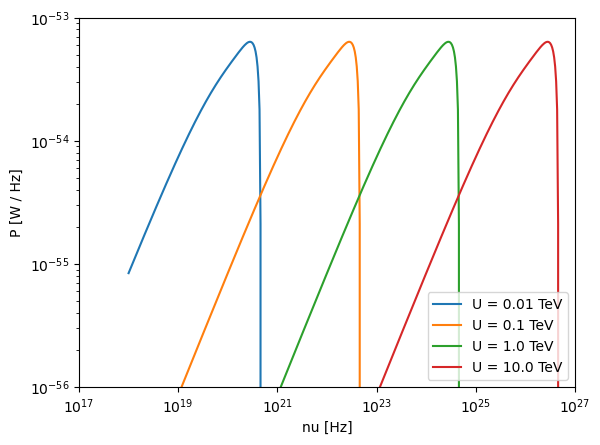

In [39]:
# your code here
frequencies = np.logspace(18, 28, 501) * u.Hz
g1 = gamma_fromEtot(0.01 * u.TeV)
g2 = gamma_fromEtot(0.1 * u.TeV)
g3 = gamma_fromEtot(1 * u.TeV)
g4 = gamma_fromEtot(10 * u.TeV)
ic1 = ICspectrum(g1, frequencies)
ic2 = ICspectrum(g2, frequencies)
ic3 = ICspectrum(g3, frequencies)
ic4 = ICspectrum(g4, frequencies)
ic1 *= (c.h * frequencies)
ic2 *= (c.h * frequencies)
ic3 *= (c.h * frequencies)
ic4 *= (c.h * frequencies)
ic1 = ic1.to(u.W / u.Hz)
print(ic1.unit)
plt.loglog(frequencies, ic1, label = 'U = 0.01 TeV')
plt.loglog(frequencies, ic2, label = 'U = 0.1 TeV')
plt.loglog(frequencies, ic3, label = 'U = 1.0 TeV')
plt.loglog(frequencies, ic4, label = 'U = 10.0 TeV')
plt.xlabel('nu [{}]'.format(frequencies.unit))
plt.ylabel('P [{}]'.format(ic1.unit))
plt.legend()
plt.ylim(1e-56,1e-53)
plt.xlim(1e17, 1e27)

Expected output:


For the second plot the electron energy is fixed to 1 TeV and the incoming photons should have frequencies of $3\times10^{10}\,\mathsf{Hz}$, $3\times10^{11}\,\mathsf{Hz}$, and $3\times10^{12}\,\mathsf{Hz}$.

In [26]:
U = 1 * u.TeV
nu_0 = [3e10, 3e11, 3e12]*u.Hz

In [40]:
#your code here
frequencies = np.logspace(18, 28, 501) * u.Hz
gamma21 = gamma_fromEtot(U)
gamma22 = gamma_fromEtot(U)
gamma23 = gamma_fromEtot(U)
ic21 = ICspectrum(gamma21, frequencies, nu_0 = nu_0[0])
ic22 = ICspectrum(gamma22, frequencies, nu_0 = nu_0[1])
ic23 = ICspectrum(gamma23, frequencies, nu_0 = nu_0[2])
ic21 *= (c.h * frequencies)  
ic22 *= (c.h * frequencies)
ic23 *= (c.h * frequencies)
plt.loglog(frequencies, ic21, label = 'ν_0 = 3e+10 Hz')
plt.loglog(frequencies, ic22, label = 'ν_0 = 3e+11 Hz')
plt.loglog(frequencies, ic23, label = 'ν_0 = 3e+12 Hz')
plt.xlabel('nu [{}]'.format(frequencies.unit))
plt.ylabel('P [{}]'.format(ic1.unit))
plt.legend()
plt.ylim(1e-56, 1e-53)
plt.xlim(1e20, 1e26)

ValueError: operands could not be broadcast together with shapes (501,) (100,) 

Expected output:


## Submission

Before you submit your work you should make a few checks that everything works fine.

1. Save your notebook as a PDF (File->Download As->PDF). This document will help you debugging in the next step.
1. If PDF export does not work: You can do File->Print Preview and then print to a file.
1. Restart the kernel and rerun the entire notebook (Kernel->Restart & Run All). This will delete all variables (but not your code) and rerun the notebook in one go. If this does not go through the endthen you have to fix it. You will see at which cell the run stopped. A common mistake is using a variable that is defined only at a later stage.
1. You think you fixed everything? Redo step 2 (Kernel->Restart & Run All)

You have to download and submit 2 files, the jupyter notebook and a pdf.
- Jupyter notebook. File->Download As->Notebook (.ipynb). Save this file on your disk.
- PDF file. File->Download As->PDF. Save this file on your disk.
- If PDF export does not work. You can do File->Print Preview and then print to a file.

Please submit the two files on Ulwazi.